In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import torch
from torch import Tensor

from torchxai.metrics._utils.common import (
    _construct_default_feature_mask,
    _reduce_attribution_over_features,
)


def _compute_locality_scores(
    attr: Tensor,  # [G]
    centers: Tensor,  # [G, 2]
    target_index: int,
    x_threshold: float,
    y_threshold: float,
) -> Tensor:
    attr = attr.clamp(min=0)  # zero out negative attributions

    if attr.sum() <= 1e-8:
        return torch.zeros(3, device=attr.device)

    # normalize attributions to sum to 1 for weighted locality scores
    w = attr 

    target_center = centers[target_index]
    dx = centers[:, 0] - target_center[0]
    dy = centers[:, 1] - target_center[1]

    print("X groups within x_threshold:", w[dx.abs() <= x_threshold])
    print("Y groups within y_threshold:", w[dy.abs() <= y_threshold])
    x_locality = w[dx.abs() <= x_threshold].sum()
    y_locality = w[dy.abs() <= y_threshold].sum()
    rms_distance = torch.sqrt((w * (dx**2 + dy**2)).sum())

    return torch.stack([x_locality, y_locality, rms_distance])


def _locality_single_sample(
    attributions_single_sample: tuple[Tensor, ...],
    feature_mask_single_sample: tuple[Tensor, ...] | None,
    bboxes_single_sample: tuple[Tensor, ...],
    target_index: int,
    x_threshold: float,
    y_threshold: float,
    use_weighted_sum: bool = False,
) -> Tensor:
    """
    Returns
    -------
    Tensor of shape [n_modalities, 3]
    """
    if not isinstance(attributions_single_sample, tuple):
        attributions_single_sample = (attributions_single_sample,)

    assert attributions_single_sample[0].shape[0] == 1

    if feature_mask_single_sample is None:
        feature_mask_single_sample = _construct_default_feature_mask(
            attributions_single_sample
        )

    reduced_attributions = _reduce_attribution_over_features(
        attributions_single_sample,
        feature_mask_single_sample,
        use_weighted_sum=use_weighted_sum,
    )  # [1, G]

    # map each bbox to its feature group id, same way we build modality_ids
    # bboxes_single_sample[mod] is [1, n_groups_mod, 4]
    all_bboxes = torch.cat([
        bbox[0].float()  # [n_groups_mod, 4]
        for bbox in bboxes_single_sample
    ], dim=0)  # [G_total, 4]
    
    centers = torch.stack([
        (all_bboxes[:, 0] + all_bboxes[:, 2]) / 2,
        (all_bboxes[:, 1] + all_bboxes[:, 3]) / 2,
    ], dim=-1)  # [G_total, 2]

    return _compute_locality_scores(
        attr=reduced_attributions,
        centers=centers,
        target_index=target_index,
        x_threshold=x_threshold,
        y_threshold=y_threshold,
    )  # [3]


def attribution_locality(
    attributions: tuple[Tensor, ...] | list[tuple[Tensor, ...]],
    feature_mask: tuple[Tensor, ...] | None,
    bboxes: tuple[Tensor, ...],
    target_index: int,
    x_threshold: float = 50.0,
    y_threshold: float = 50.0,
    use_weighted_sum: bool = False,
    multi_target: bool = False,
    return_dict: bool = False,
) -> dict | Tensor | list[Tensor]:
    """Compute attribution locality scores.

    Parameters
    ----------
    x_threshold : float
        Maximum x-distance from target center to count as local (in pixels/units).
    y_threshold : float
        Maximum y-distance from target center to count as local (in pixels/units).

    Returns
    -------
    Tensor of shape [batch_size, n_modalities, 3] where dim -1 is
    [x_locality, y_locality, rms_distance], or list thereof (multi_target).
    If return_dict=True:
        {"x_locality": [batch, n_mod], "y_locality": [batch, n_mod], "rms_distance": [batch, n_mod]}
    """
    is_list = isinstance(attributions, list)
    if multi_target:
        assert is_list, "attributions must be a list of tuples when multi_target=True"
    if not is_list:
        attributions = [attributions]

    scores = []
    for attribution in attributions:
        bsz = attribution[0].size(0)
        batch_scores = []

        for i in range(bsz):
            score = _locality_single_sample(
                attributions_single_sample=tuple(
                    attr[i].unsqueeze(0) for attr in attribution
                ),
                feature_mask_single_sample=(
                    tuple(mask[i].unsqueeze(0) for mask in feature_mask)
                    if feature_mask is not None
                    else None
                ),
                bboxes_single_sample=tuple(bbox[i].unsqueeze(0) for bbox in bboxes),
                target_index=target_index,
                x_threshold=x_threshold,
                y_threshold=y_threshold,
                use_weighted_sum=use_weighted_sum,
            )
            batch_scores.append(score)

        scores.append(torch.stack(batch_scores))  # [batch_size, n_modalities, 3]

    if not is_list:
        scores = scores[0]

    if return_dict:
        if isinstance(scores, list):
            return {
                "x_locality": [s[..., 0] for s in scores],
                "y_locality": [s[..., 1] for s in scores],
                "rms_distance": [s[..., 2] for s in scores],
            }
        return {
            "x_locality": scores[..., 0],  # [batch_size, n_modalities]
            "y_locality": scores[..., 1],
            "rms_distance": scores[..., 2],
        }

    return scores


In [52]:
import torch

# from torchxai.metrics.diagnosis.attribution_locality import attribution_locality

# ── dimensions ────────────────────────────────────────────────────────────────
BATCH     = 1
SEQ_LEN   = 512
DIM       = 768
N_GROUPS1 = 50
N_GROUPS2 = 40

# ── attributions: [batch, seq_len, dim] → summed to [batch, seq_len] ─────────
attr1 = torch.randn(BATCH, SEQ_LEN, DIM)
attr2 = torch.randn(BATCH, SEQ_LEN, DIM)

attributions = (attr1, attr2)

# ── feature masks ─────────────────────────────────────────────────────────────
def make_feature_mask(batch, seq_len, n_groups):
    mask = torch.zeros(batch, seq_len, dtype=torch.long)
    for b in range(batch):
        base = torch.arange(n_groups)
        rest = torch.randint(0, n_groups, (seq_len - n_groups,))
        perm = torch.cat([base, rest])[torch.randperm(seq_len)]
        mask[b] = perm
    return mask

mask1 = make_feature_mask(BATCH, SEQ_LEN, N_GROUPS1).unsqueeze(-1).expand_as(attr1)
mask2 = make_feature_mask(BATCH, SEQ_LEN, N_GROUPS2).unsqueeze(-1).expand_as(attr2) + N_GROUPS1

feature_mask = (mask1, mask2)

# ── bboxes: one per group, shape [batch, n_groups, 4] → (x1, y1, x2, y2) ────
# for a 2D spatial layout, simulate groups laid out on a grid
def make_bboxes(batch, n_groups, image_size=224, box_size=20):
    """Random bounding boxes for each group in [0, image_size]."""
    x1 = torch.randint(0, image_size - box_size, (batch, n_groups)).float()
    y1 = torch.randint(0, image_size - box_size, (batch, n_groups)).float()
    x2 = x1 + box_size
    y2 = y1 + box_size
    return torch.stack([x1, y1, x2, y2], dim=-1)  # [batch, n_groups, 4]

bboxes1 = make_bboxes(BATCH, N_GROUPS1)  # [4, 50, 4]
bboxes2 = make_bboxes(BATCH, N_GROUPS2)  # [4, 40, 4]

bboxes = (bboxes1, bboxes2)

# ── target index: which group is the target (same for all samples here) ───────
TARGET_INDEX = 5  # must be < min(N_GROUPS1, N_GROUPS2)

# ── sanity checks ─────────────────────────────────────────────────────────────
print("attr1 shape      :", attr1.shape)                          # [4, 512, 768]
print("attr2 shape      :", attr2.shape)                          # [4, 512, 768]
print("mask1 shape      :", mask1.shape)                          # [4, 512, 768]
print("mask2 shape      :", mask2.shape)                          # [4, 512, 768]
print("mask1 unique[0]  :", mask1[0, :, 0].unique().shape[0], "groups")  # 50
print("mask2 unique[0]  :", mask2[0, :, 0].unique().shape[0], "groups")  # 40
print("bboxes1 shape    :", bboxes1.shape)                        # [4, 50, 4]
print("bboxes2 shape    :", bboxes2.shape)                        # [4, 40, 4]

# ── run metric ────────────────────────────────────────────────────────────────
result = attribution_locality(
    attributions=attributions,
    feature_mask=feature_mask,
    bboxes=bboxes,
    target_index=TARGET_INDEX,
    x_threshold=10.0,
    y_threshold=10.0,
    return_dict=True,
)

print("\nx_locality   :", result["x_locality"].shape)    # [4, 2]
print("y_locality   :", result["y_locality"].shape)    # [4, 2]
print("rms_distance :", result["rms_distance"].shape)  # [4, 2]
print("\nx_locality:\n",   result["x_locality"])
print("\ny_locality:\n",   result["y_locality"])
print("\nrms_distance:\n", result["rms_distance"])

attr1 shape      : torch.Size([1, 512, 768])
attr2 shape      : torch.Size([1, 512, 768])
mask1 shape      : torch.Size([1, 512, 768])
mask2 shape      : torch.Size([1, 512, 768])
mask1 unique[0]  : 50 groups
mask2 unique[0]  : 40 groups
bboxes1 shape    : torch.Size([1, 50, 4])
bboxes2 shape    : torch.Size([1, 40, 4])
X groups within x_threshold: tensor([  0.0000,   6.9130,  92.3105, 145.6975,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000])
Y groups within y_threshold: tensor([  0.0000,   6.9130,  82.7456,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,  86.8079,  30.3623,   0.0000, 161.0562,  93.7726])

x_locality   : torch.Size([1])
y_locality   : torch.Size([1])
rms_distance : torch.Size([1])

x_locality:
 tensor([244.9210])

y_locality:
 tensor([461.6575])

rms_distance:
 tensor([5896.7715])


tensor([  21.1229, -301.4521, -191.8801, -130.0947,  -25.7204,    6.9130,
         -43.3158,  -34.4836,   82.7458,   -8.1560,    2.1519,  -57.3518,
          88.0883,   67.1097,   24.0690,    1.7199,  -21.0444,    1.7318,
         -96.0373,   92.3104,   19.0869,  145.6976,  -61.3391,   16.8487,
         335.2909,   92.2510,  -18.6623, -129.3819,  -49.2029,  -45.8956,
          -8.9511, -276.2733,   -3.3727,  -88.5220,  -27.0163,    1.2518,
         117.6831,  -36.4345,  -33.3083,  -76.9315,  -85.2070, -154.0056,
          10.6389,    5.3546,   15.6674, -116.7156,   86.8079,  190.1985,
          87.0195,   54.8149])
tensor([ 200.1894,   -8.4895,   30.3623,   99.4188,   92.3763, -124.4540,
          68.1329,   60.9474,  -83.9029,  -22.2802,  -20.0982,  -64.7326,
         -90.4566,  -43.9186,  114.7921, -188.9776,  -10.8513,  -81.8178,
        -121.3663, -136.6065, -143.2819,   55.4470,   69.0100,   77.2716,
          99.0057,  -85.7325,   35.2816,   16.1521,  -84.6088,  -81.1187,
       

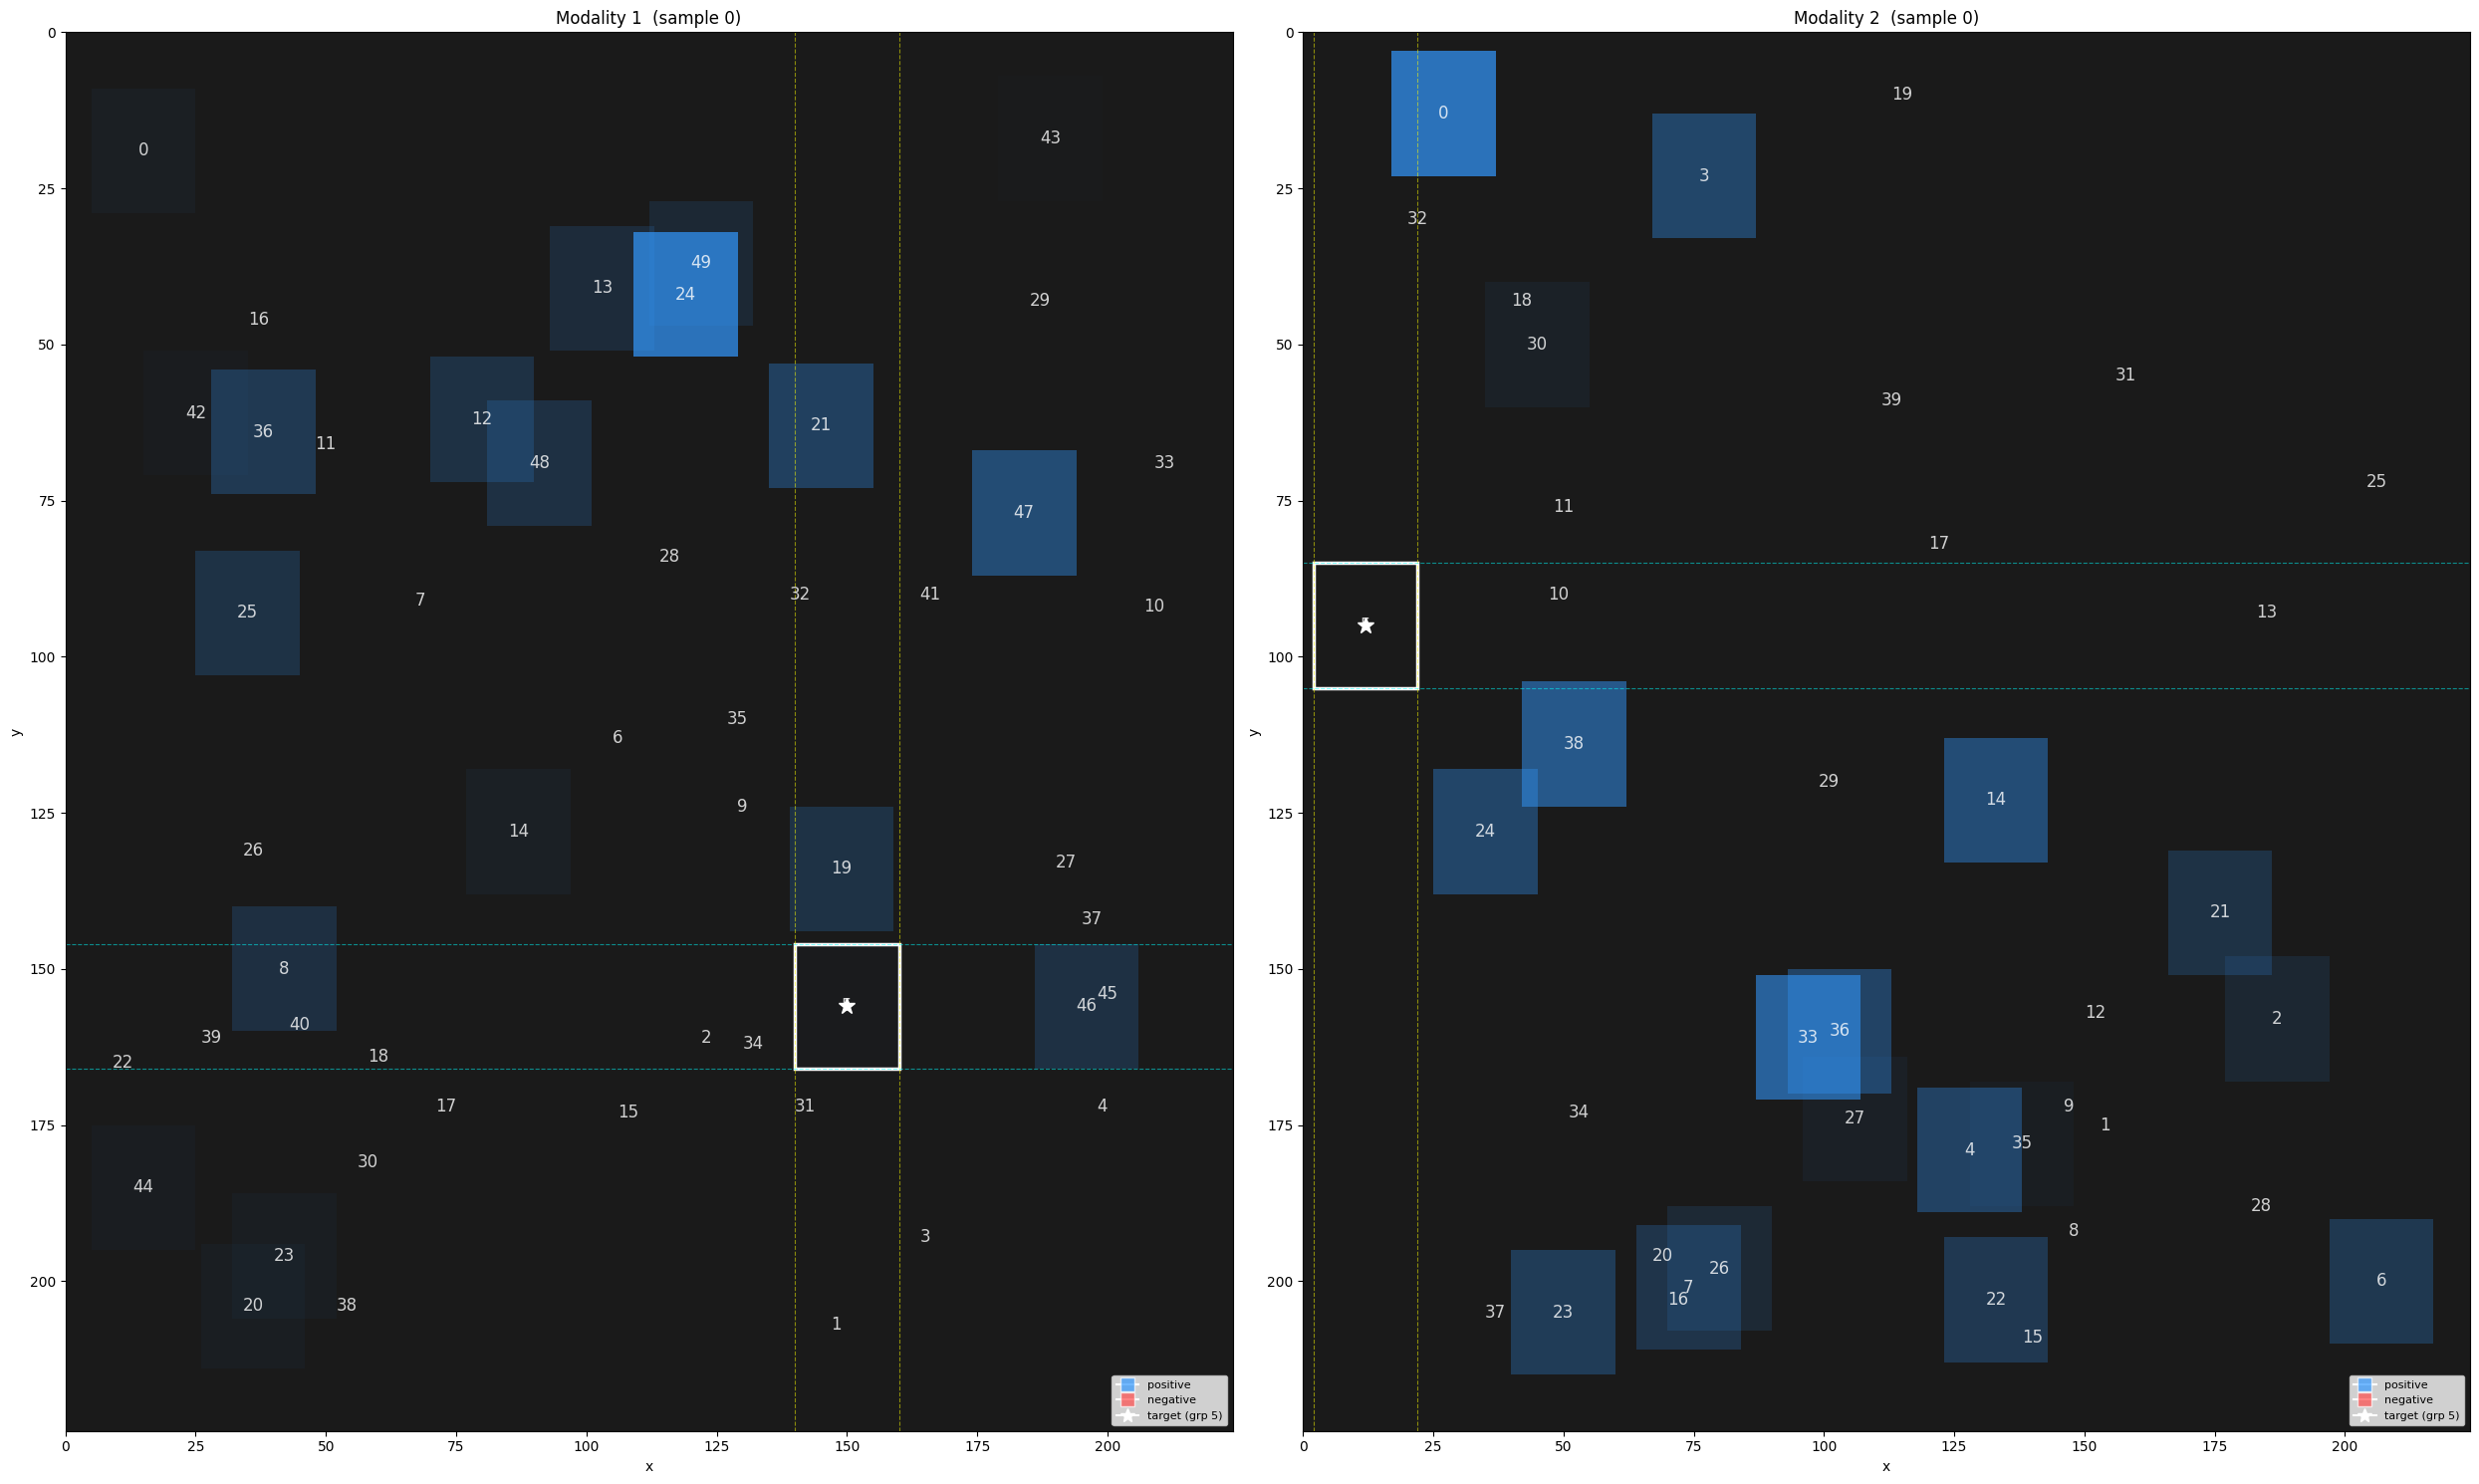

saved → locality_viz.png

x_locality   : torch.Size([1])
y_locality   : torch.Size([1])
rms_distance : torch.Size([1])

x_locality:
 tensor([244.9210])

y_locality:
 tensor([461.6575])

rms_distance:
 tensor([5896.7715])


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch

torch.manual_seed(42)

BATCH        = 4
N_GROUPS1    = 50
N_GROUPS2    = 40
TARGET_INDEX = 5
IMAGE_SIZE   = 224
BOX_SIZE     = 20

# ── reduce attributions per group ─────────────────────────────────────────────
def reduce_groups(attr_3d, mask_3d):
    # attr_3d: [seq_len, dim], mask_3d: [seq_len, dim]
    attr = attr_3d.sum(-1)   # [seq_len]
    mask = mask_3d[:, 0]     # [seq_len]
    groups = mask.unique()
    reduced = torch.zeros(len(groups))  # ensure enough space for all group ids
    for idx, g in enumerate(groups):
        reduced[idx] = attr[mask == g].sum()
    return reduced  # [n_groups]

# reuse your existing tensors: attr1, attr2, mask1, mask2, bboxes1, bboxes2
# pick sample to visualize
SAMPLE = 0

red1 = reduce_groups(attr1[SAMPLE], mask1[SAMPLE])  # [50]
red2 = reduce_groups(attr2[SAMPLE], mask2[SAMPLE])  # [40]

print(red1)
print(red2)

b1 = bboxes1[SAMPLE]  # [50, 4]
b2 = bboxes2[SAMPLE]  # [40, 4]

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(25, 15))

for ax, red, bboxes_b, n_groups, title in [
    (axes[0], red1, b1, N_GROUPS1, "Modality 1"),
    (axes[1], red2, b2, N_GROUPS2, "Modality 2"),
]:
    ax.set_xlim(0, IMAGE_SIZE)
    ax.set_ylim(IMAGE_SIZE, 0)  # origin top-left
    ax.set_facecolor("#1a1a1a")
    ax.set_title(f"{title}  (sample {SAMPLE})", fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("y")

    # normalise for colour mapping
    red = red.clamp(min=0)  # zero out negative attributions
    vals = red.numpy()
    vmax = max(abs(vals).max(), 1e-8)

    for g in range(n_groups):
        x1, y1, x2, y2 = bboxes_b[g].tolist()
        v = vals[g]
        alpha = min(abs(v) / vmax, 1.0)

        facecolor = (0.2, 0.6, 1.0, alpha * 0.7) if v > 0 else (1.0, 0.3, 0.3, alpha * 0.7)
        edgecolor = "white" if g == TARGET_INDEX else "none"
        linewidth = 2.5 if g == TARGET_INDEX else 0

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=linewidth,
            edgecolor=edgecolor,
            facecolor=facecolor,
        )
        ax.add_patch(rect)

        # label group id on box
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(cx, cy, str(g), color="white", fontsize=12,
                ha="center", va="center", alpha=0.8)

    # mark target center
    tx1, ty1, tx2, ty2 = bboxes_b[TARGET_INDEX].tolist()
    ax.plot((tx1 + tx2) / 2, (ty1 + ty2) / 2, "w*", markersize=12, label="target")

    # threshold bands around target
    tcx, tcy = (tx1 + tx2) / 2, (ty1 + ty2) / 2
    ax.axvline(tcx - 10, color="yellow", lw=0.8, ls="--", alpha=0.5)
    ax.axvline(tcx + 10, color="yellow", lw=0.8, ls="--", alpha=0.5, label="x_thresh")
    ax.axhline(tcy - 10, color="cyan",   lw=0.8, ls="--", alpha=0.5)
    ax.axhline(tcy + 10, color="cyan",   lw=0.8, ls="--", alpha=0.5, label="y_thresh")

    ax.legend(fontsize=8, loc="upper right")

    # colorbar proxy
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0], [0], marker="s", color="w", markerfacecolor=(0.2, 0.6, 1.0, 0.7), markersize=10, label="positive"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor=(1.0, 0.3, 0.3, 0.7), markersize=10, label="negative"),
        Line2D([0], [0], marker="*", color="white", markersize=10, label=f"target (grp {TARGET_INDEX})"),
    ]
    ax.legend(handles=legend_els, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("locality_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved → locality_viz.png")

print("\nx_locality   :", result["x_locality"].shape)    # [4, 2]
print("y_locality   :", result["y_locality"].shape)    # [4, 2]
print("rms_distance :", result["rms_distance"].shape)  # [4, 2]
print("\nx_locality:\n",   result["x_locality"])
print("\ny_locality:\n",   result["y_locality"])
print("\nrms_distance:\n", result["rms_distance"])